We can $\Delta$ hedge with CEV models. The definition of delta is still the same:
$$
\Delta = \partial C/ \partial S
$$
So $\Delta$ is the rate of change of price in our call option with respect to the underlying stock price movement. 
However unlike with GBM, we cannot always get a closed form solution to find $\Delta$, and so must use Montle Carlo methods/numerical approximations to find Delta.

The code in this notebook shows how we can compute $\Delta$ through Monte Carlo Methods. However The actual Delta Hedging is not implemented here.

0.6807798759828172


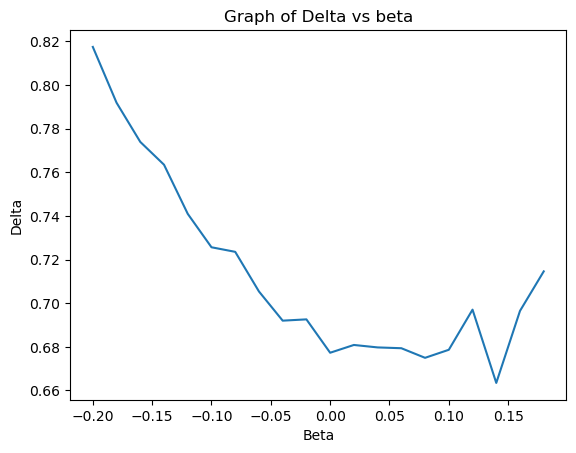

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson
import yfinance as yf
from scipy.optimize import least_squares
S0 = 100
T = 1
N = 252
sigma = 0.3
n_paths = 10000
r = 0.10 
dt = T / N
K=100

def Call_delta_CEV(S=S0,beta = 0, h=0.02):
    #Estimate delta of a call option under CEV model using finite differences.
    h = S*h
    Z = np.random.randn(n_paths, N)
    def price_from(S):
        # simulate paths starting from S
        
        paths = np.zeros((n_paths, N+1))
        paths[:,0] = S
        dt = T / N
        for t in range(N):
            S_t = paths[:,t]
            paths[:,t+1] = S_t + (r*S_t*dt + sigma*(S_t**(beta+1))*np.sqrt(dt)*Z[:,t])
            paths[:,t+1] = np.maximum(paths[:,t+1],1e-8)
        S_T = paths[:,-1]
        payoff = np.maximum(S_T - K, 0)
        return np.exp(-r*T) * np.mean(payoff)
    
    return  (price_from(S+h) - price_from(S-h))/(2*h)

betas = np.arange(-0.2,0.2,0.02)
Deltas = [Call_delta_CEV(beta =b) for b in betas]
plt.plot(betas,Deltas)
plt.title('Graph of Delta vs beta')
plt.xlabel('Beta')
plt.ylabel('Delta')
print(Call_delta_CEV())